# Úkol 3


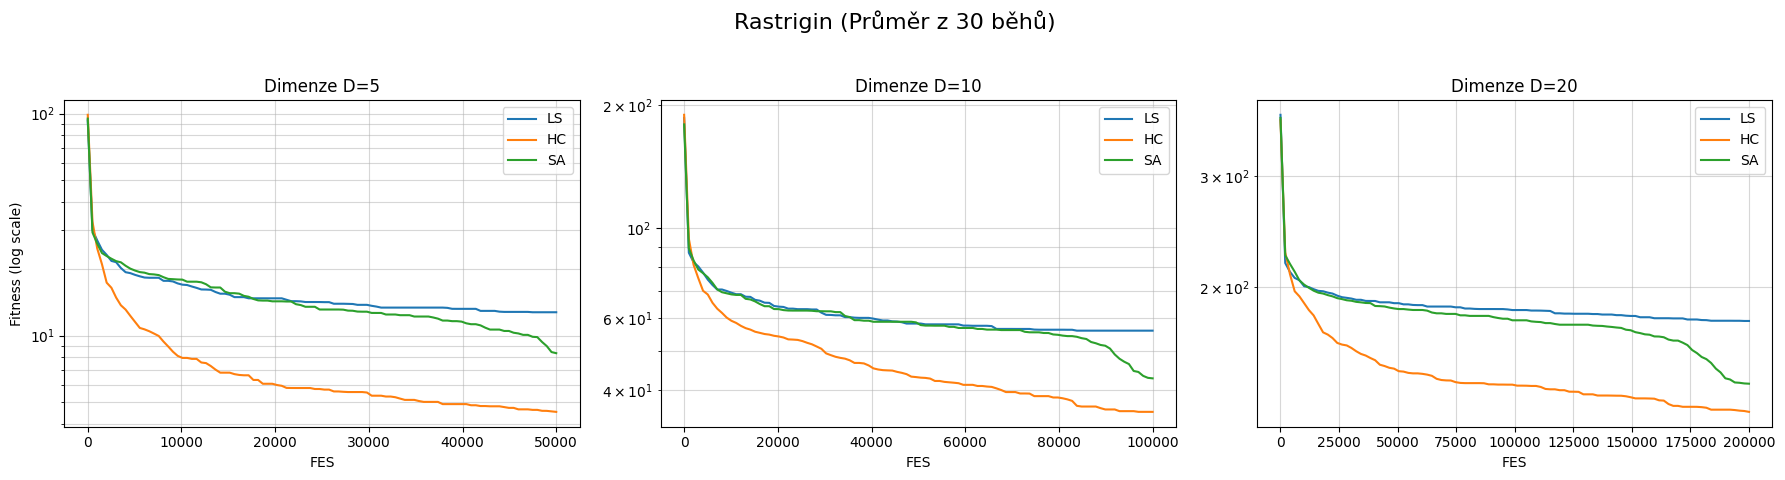

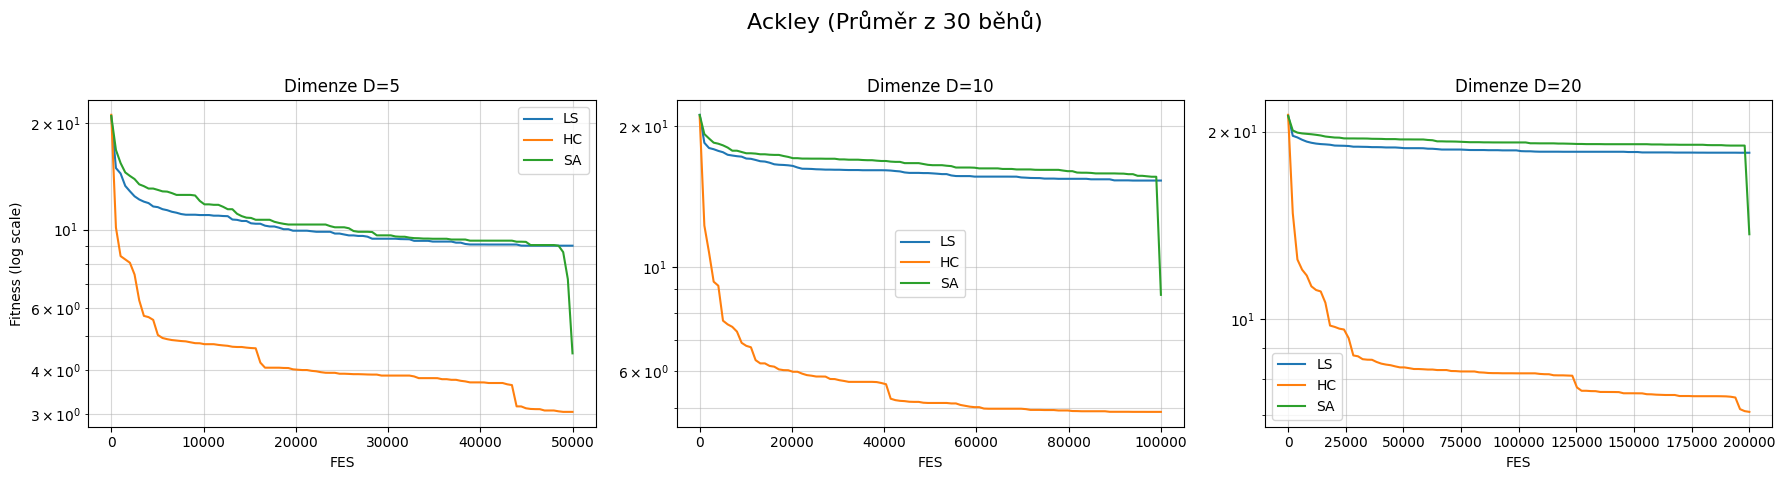

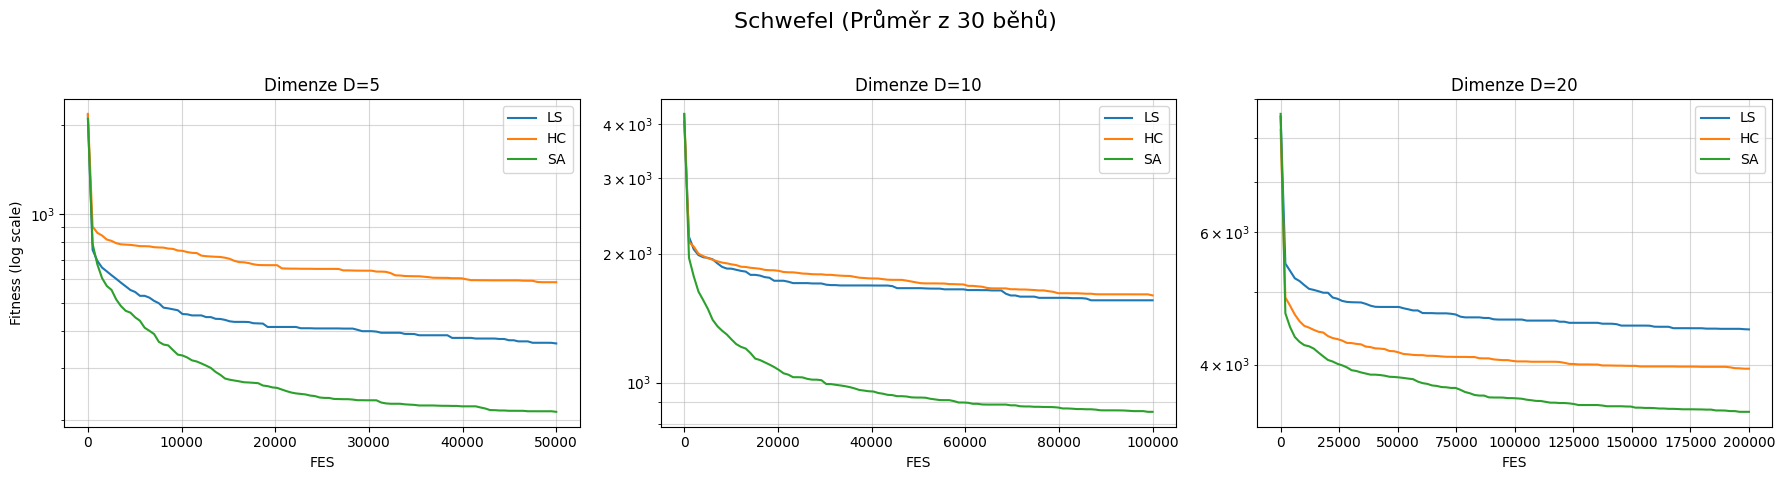

Funkce,Dimenze,Metoda,Nejlepší,Nejhorší,Průměr,Medián,Std
Rastrigin,5,LS,7.489103,17.481662,12.735618,12.487766,2.555058
Rastrigin,5,HC,2.071691,7.662347,4.531911,4.286104,1.543650
Rastrigin,5,SA,5.180058,13.155181,8.330038,7.938790,1.696694
Rastrigin,10,LS,44.102759,67.058566,55.981988,55.434783,5.138206
Rastrigin,10,HC,20.927226,68.321351,35.395872,33.886949,10.712034
Rastrigin,10,SA,32.925139,55.747051,42.766652,41.988373,6.491541
Rastrigin,20,LS,154.946978,190.009256,176.626582,179.370243,9.997393
Rastrigin,20,HC,102.526096,177.617034,126.689530,119.002595,18.811489
Rastrigin,20,SA,112.630662,163.456375,140.431716,139.076102,11.153645
Ackley,5,LS,6.027162,10.797195,9.005857,9.168437,1.141744


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

def rastrigin(x):
    d = x.shape[-1]
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=-1)

def ackley(x):
    d = x.shape[-1]
    term1 = -20 * np.exp(-0.2 * np.sqrt(np.sum(x**2, axis=-1) / d))
    term2 = -np.exp(np.sum(np.cos(2 * np.pi * x), axis=-1) / d)
    return term1 + term2 + 20 + np.e

def schwefel(x):
    d = x.shape[-1]
    return 418.9829 * d - np.sum(x * np.sin(np.sqrt(np.abs(x))), axis=-1)

FUNCTIONS = {
    "Rastrigin": (rastrigin, -5.12, 5.12),
    "Ackley": (ackley, -32.768, 32.768),
    "Schwefel": (schwefel, -500.0, 500.0)
}

def apply_bounds(x, low, high):
    return np.clip(x, low, high)

def local_search(func, dim, low, high, max_fes, pop_size=10):
    best_x = np.random.uniform(low, high, dim)
    best_f = func(best_x)
    fes = 1
    curve = [(fes, best_f)]
    
    while fes < max_fes:
        evals_left = min(pop_size, max_fes - fes)
        candidates = np.random.uniform(low, high, (evals_left, dim))
        for c in candidates:
            f = func(c)
            fes += 1
            if f < best_f:
                best_f = f
                best_x = c
        curve.append((fes, best_f))
    return best_f, best_x, np.array(curve)

def hill_climbing(func, dim, low, high, max_fes, neighbors=10, sigma=0.05):
    curr_x = np.random.uniform(low, high, dim)
    curr_f = func(curr_x)
    best_x = np.copy(curr_x)
    best_f = curr_f
    fes = 1
    curve = [(fes, best_f)]
    range_val = high - low
    
    while fes < max_fes:
        evals_left = min(neighbors, max_fes - fes)
        candidates = curr_x + np.random.normal(0, sigma * range_val, (evals_left, dim))
        candidates = apply_bounds(candidates, low, high)
        
        for c in candidates:
            cand_f = func(c)
            fes += 1
            if cand_f < curr_f:
                curr_f = cand_f
                curr_x = c
                if curr_f < best_f:
                    best_f = curr_f
                    best_x = np.copy(curr_x)
        curve.append((fes, best_f))
    return best_f, best_x, np.array(curve)

def simulated_annealing(func, dim, low, high, max_fes, neighbors=10, sigma=0.05, T0=100.0, Tf=0.01):
    curr_x = np.random.uniform(low, high, dim)
    curr_f = func(curr_x)
    best_x = np.copy(curr_x)
    best_f = curr_f
    fes = 1
    curve = [(fes, best_f)]
    range_val = high - low
    Imax = max_fes // neighbors
    
    for i in range(Imax):
        if fes >= max_fes: break
        
        T_i = T0 - i * (T0 - Tf) / Imax
        T_i = max(T_i, Tf)
        
        for _ in range(neighbors):
            if fes >= max_fes: break
            candidate = curr_x + np.random.normal(0, sigma * range_val, dim)
            candidate = apply_bounds(candidate, low, high)
            cand_f = func(candidate)
            fes += 1
            
            if cand_f < curr_f:
                curr_x = candidate
                curr_f = cand_f
                if cand_f < best_f:
                    best_f = cand_f
                    best_x = np.copy(candidate)
            else:
                p_accept = np.exp(-(cand_f - curr_f) / T_i)
                if np.random.rand() < p_accept:
                    curr_x = candidate
                    curr_f = cand_f
                    
        curve.append((fes, best_f))
    return best_f, best_x, np.array(curve)

def interpolate_curve(curve, max_fes):
    fes_points = curve[:, 0]
    fit_points = curve[:, 1]
    full_fes = np.linspace(1, max_fes, 100)
    full_fit = np.interp(full_fes, fes_points, fit_points)
    return full_fes, full_fit

def run_experiments():
    dimensions = [5, 10, 20]
    runs = 30
    results = []
    
    for func_name, (func, low, high) in FUNCTIONS.items():
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"{func_name} (Průměr z {runs} běhů)", fontsize=16)
        
        for idx, d in enumerate(dimensions):
            max_fes = 10000 * d
            all_curves = {"LS": [], "HC": [], "SA": []}
            all_bests = {"LS": [], "HC": [], "SA": []}
            
            for r in range(runs):
                res_ls = local_search(func, d, low, high, max_fes)
                res_hc = hill_climbing(func, d, low, high, max_fes)
                res_sa = simulated_annealing(func, d, low, high, max_fes)
                
                for name, res in zip(["LS", "HC", "SA"], [res_ls, res_hc, res_sa]):
                    all_bests[name].append(res[0])
                    fes_ax, fit_interp = interpolate_curve(res[2], max_fes)
                    all_curves[name].append(fit_interp)
            
            for name in ["LS", "HC", "SA"]:
                bests = all_bests[name]
                results.append({
                    "Funkce": func_name, "Dimenze": d, "Metoda": name,
                    "Nejlepší": np.min(bests), "Nejhorší": np.max(bests),
                    "Průměr": np.mean(bests), "Medián": np.median(bests),
                    "Std": np.std(bests)
                })
            
            ax = axes[idx]
            fes_range = np.linspace(1, max_fes, 100)
            ax.plot(fes_range, np.mean(all_curves["LS"], axis=0), label="LS")
            ax.plot(fes_range, np.mean(all_curves["HC"], axis=0), label="HC")
            ax.plot(fes_range, np.mean(all_curves["SA"], axis=0), label="SA")
            
            ax.set_yscale("log")
            ax.set_title(f"Dimenze D={d}")
            ax.set_xlabel("FES")
            if idx == 0:
                ax.set_ylabel("Fitness (log scale)")
            ax.legend()
            ax.grid(True, which="both", ls="-", alpha=0.5)
            
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
            
    df_results = pd.DataFrame(results)
    display(HTML("<h3>Tabulka se základní statistikou</h3>"))
    display(HTML(df_results.to_html(index=False, classes='table table-striped')))

run_experiments()


## Komentář

| Funkce | Definiční obor | Globální minimum | Souřadnice minima |
| --- | --- | --- | --- |
| Rastrigin | $[-5.12, 5.12]^D$ | $f(x^*) = 0$ | $[0, \dots, 0]$ |
| Ackley | $[-32.768, 32.768]^D$ | $f(x^*) = 0$ | $[0, \dots, 0]$ |
| Schwefel | $[-500, 500]^D$ | $f(x^*) \approx 0$ | $[420.97, \dots, 420.97]$ |

---

**Nastavení experimentů:**
* **Dimenze:** $D \in \{5, 10, 20\}$
* **MaxFES:** $10000 \cdot D$
* **Počet běhů:** 30
* **Velikost okolí ($\sigma$):** $0.05$ (násobeno rozsahem funkce)
* **Parametry SA:** $T_0 = 100$, $T_f = 0.01$
* **Ochlazování:** $T(i) = T_0 - i \cdot \frac{T_0 - T_f}{I_{max}}$ — lineární pokles teploty

**Ošetření hranic:** Pro zajištění přípustnosti kandidátů jsem zvolil metodu oříznutí (`np.clip`). 
Pokud vygenerovaný soused přesáhne meze definičního oboru, je jednoduše přisunut na nejbližší 
přípustnou hranici. Nevýhoda oříznutí spočívá v tom, že při vysokém $\sigma$ se body mohou 
nahromadit na okrajích prostoru — v praxi jsem to ale pozoroval jen zřídka, protože $\sigma = 0.05$ 
rozsahu funkce je relativně malé.

---

**Analýza funkcí**

**Rastrigin** má hustou pravidelnou síť lokálních minim, což je klasická past pro HC — jakmile 
algoritmus sjede do nejbližšího důlku, nemá šanci se z něj dostat. SA si s tím poradí díky tomu, 
že při vyšších teplotách horší řešení přijímá s nezanedbatelnou pravděpodobností, a tak dokáže 
tuto síť prohledávat globálněji. S rostoucí dimenzí se rozdíl mezi SA a HC prohlubuje.

**Ackley** je zajímavý tím, že má poměrně plochý reliéf daleko od středu a prudce klesá 
v centrální oblasti. To trochu smazává výhodu SA oproti LS — i náhodné vzorkování z LS má 
slušnou šanci trefit tuto oblast. Přesto SA v průměru dosahuje lepších výsledků, zvlášť 
ve vyšších dimenzích.

**Schwefel** mě ze všech tří funkcí překvapil nejvíce. Globální minimum leží u souřadnic přibližně 
$[420.97, \dots, 420.97]$, tedy daleko od středu prostoru — a algoritmy inicializované náhodně 
sklouznou ke zdánlivě atraktivnímu minimu poblíž nuly. HC se z této pasti téměř nikdy nedostane. 
SA to zvládne díky přijímání horších řešení, ale ani tak nedosahuje globálního optima spolehlivě, 
zejména při $D = 20$.

---

**Zhodnocení výsledků a vliv parametrů**

Z výsledků je vidět, že **SA** na všech třech funkcích překonává HC i LS, přičemž největší rozdíl 
je právě u Rastriginu a Schwefelu. LS bez jakékoliv lokální paměti působí na první pohled jako 
slabý soupeř, ale u komplexních funkcí s hustými lokálními minimy překvapivě nezaostává za HC 
tak výrazně, jak by se dalo čekat.

Parametr $T_0$ má zásadní vliv na to, jak moc se SA v počáteční fázi hledá v prostoru. 
Pro zvolené hodnoty $T_0 = 100$, $T_f = 0.01$ funguje nastavení rozumně u Rastriginu a Ackley, 
kde jsou hodnoty fitness v řádu desítek až stovek. U Schwefelu jsou však funkční hodnoty 
řádově vyšší (stovky až tisíce), takže pravděpodobnost přijetí je i při $T_0 = 100$ prakticky nulová — a SA se v raných iteracích chová skoro jako HC. 
Vhodná hodnota $T_0$ by pro Schwefel měla být spíše v řádu tisíců, aby byl únik z lokálních 
minim reálně možný.

S rostoucí dimenzí výhoda SA přetrvává, ale celkový budget $10000 \cdot D$ pokrývá 
exponenciálně menší část prohledávacího prostoru. Proto se výsledky u všech tří metod 
s dimenzí zhoršují, přičemž SA si i v $D = 20$ drží konzistentně nižší rozptyl výsledků 
než HC.
